<a href="https://colab.research.google.com/github/Anonymous2004369/titanic_survival_prediction/blob/main/titanic_survival_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Prediction
## PS26 - DSC01 Machine Learning | Submission 1

**Dataset:** Titanic - Machine Learning from Disaster (Kaggle)  
**Task Type:** Binary Classification  
**Target Variable:** `Survived` (0 = No, 1 = Yes)  
**Models Used:** Logistic Regression, Decision Tree, Random Forest

## 1. Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load the Dataset

Dataset source: https://www.kaggle.com/c/titanic/data  
We load the data directly from a public URL for convenience.

In [18]:
# Load dataset from public URL
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded successfully!
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Exploratory Data Analysis (EDA)

In [19]:
# Basic info
print('=== Dataset Info ===')
print(df.info())
print('\n=== Summary Statistics ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

=== Summary Statistics ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
# Check missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

=== Missing Values ===


,Missing Count,Missing %
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


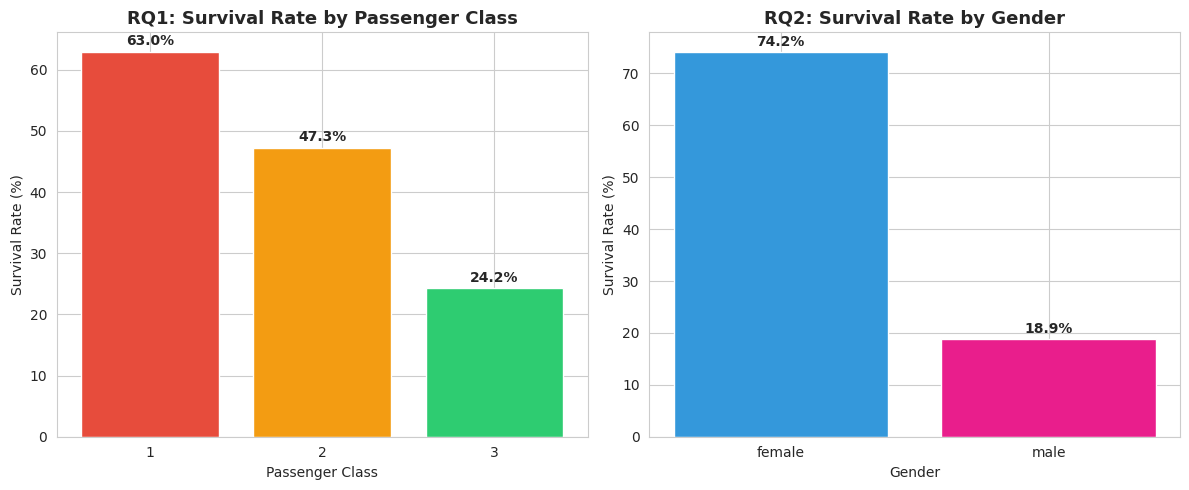

Figure saved!


In [21]:
# Research Q1: Survival rate by passenger class
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

survival_class = df.groupby('Pclass')['Survived'].mean() * 100
axes[0].bar(survival_class.index, survival_class.values, color=['#e74c3c','#f39c12','#2ecc71'])
axes[0].set_title('RQ1: Survival Rate by Passenger Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_xticks([1, 2, 3])
for i, v in enumerate(survival_class.values):
    axes[0].text(i+1, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

# Research Q2: Survival rate by gender
survival_sex = df.groupby('Sex')['Survived'].mean() * 100
axes[1].bar(survival_sex.index, survival_sex.values, color=['#3498db','#e91e8c'])
axes[1].set_title('RQ2: Survival Rate by Gender', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Survival Rate (%)')
for i, (k, v) in enumerate(survival_sex.items()):
    axes[1].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('survival_by_class_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

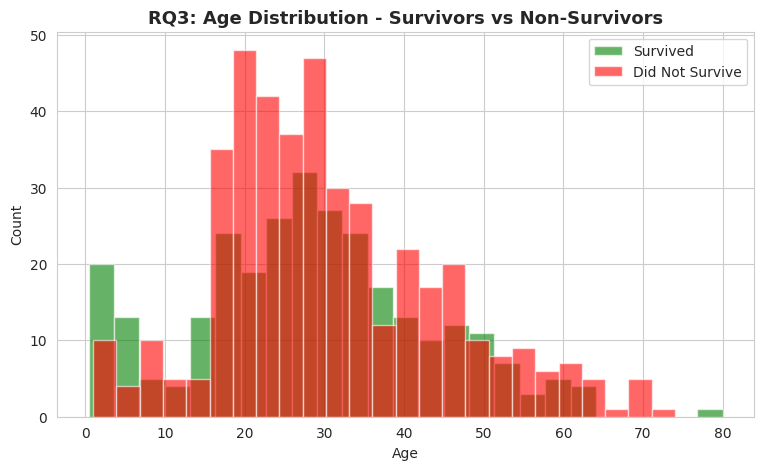

Figure saved!


In [22]:
# Research Q3: Age distribution of survivors vs non-survivors
plt.figure(figsize=(9, 5))
df[df['Survived'] == 1]['Age'].dropna().hist(bins=25, alpha=0.6, color='green', label='Survived')
df[df['Survived'] == 0]['Age'].dropna().hist(bins=25, alpha=0.6, color='red', label='Did Not Survive')
plt.title('RQ3: Age Distribution - Survivors vs Non-Survivors', fontsize=13, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.savefig('age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

<Figure size 800x500 with 0 Axes>

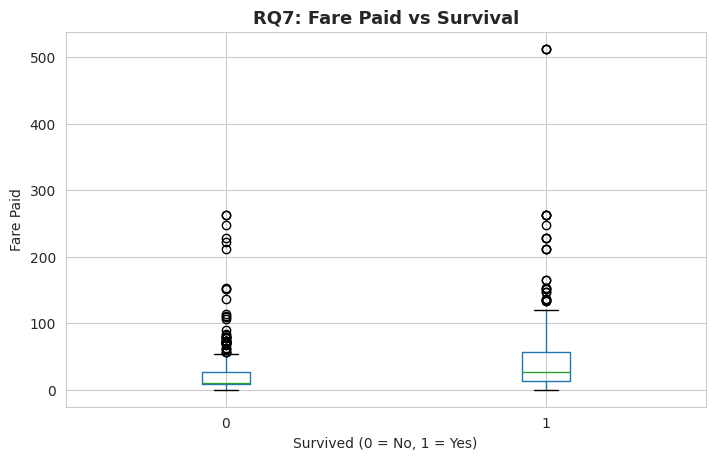

Figure saved!


In [23]:
# Research Q7: Fare vs Survival
plt.figure(figsize=(8, 5))
df.boxplot(column='Fare', by='Survived', figsize=(8,5))
plt.title('RQ7: Fare Paid vs Survival', fontsize=13, fontweight='bold')
plt.suptitle('')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare Paid')
plt.savefig('fare_vs_survival.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

## 4. Data Preprocessing

In [24]:
# Work on a copy
df_clean = df.copy()

# 1. Fill missing Age with median
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)

# 2. Fill missing Embarked with mode
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# 3. Drop Cabin (too many missing), Name, Ticket, PassengerId
df_clean.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True)

# 4. Encode Sex: male=0, female=1
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

# 5. Encode Embarked: S=0, C=1, Q=2
df_clean['Embarked'] = df_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 6. Feature Engineering: FamilySize
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch']

print('Preprocessing complete!')
print(f'Missing values remaining: {df_clean.isnull().sum().sum()}')
df_clean.head()

Preprocessing complete!
Missing values remaining: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,1,1
2,1,3,1,26.0,0,0,7.9250,0,0
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,0


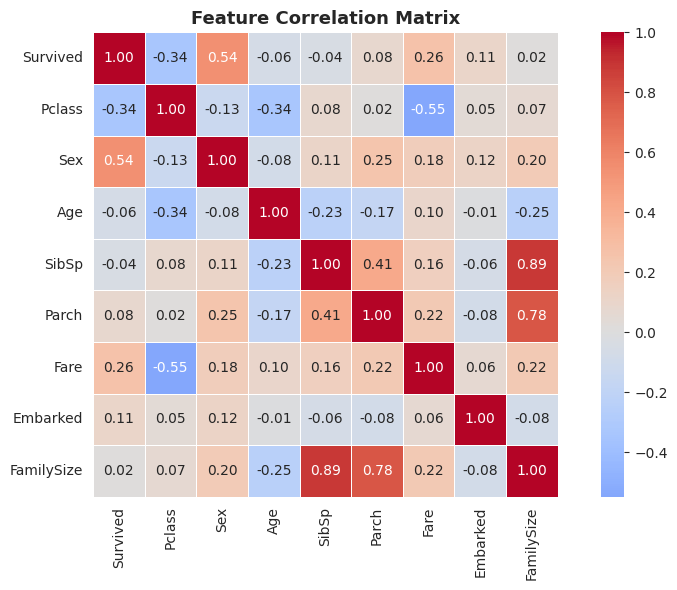

Figure saved!


In [25]:
# Correlation heatmap
plt.figure(figsize=(9, 6))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

## 5. Feature Selection & Train-Test Split

In [26]:
# Select features and target
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize']
X = df_clean[features]
y = df_clean['Survived']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Features used: {features}')

Training set: 712 samples
Test set:     179 samples
Features used: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize']


## 6. Model Training & Evaluation

In [27]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}

# Store results
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
    }
    print(f'{name}: Accuracy = {results[name]["accuracy"]:.4f}')

print('\nAll models trained and evaluated!')

Logistic Regression: Accuracy = 0.8045
Decision Tree: Accuracy = 0.7598
Random Forest: Accuracy = 0.8045

All models trained and evaluated!


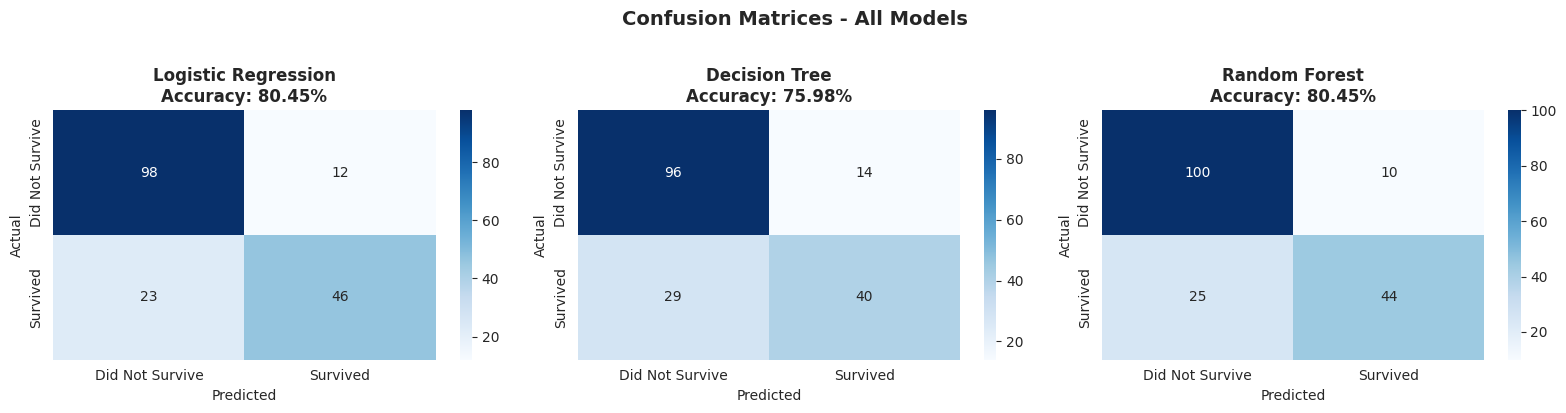

Figure saved!


In [28]:
# Confusion matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Did Not Survive','Survived'],
                yticklabels=['Did Not Survive','Survived'])
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]:.2%}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

In [29]:
# Detailed classification reports
for name, res in results.items():
    print(f'\n=== {name} ===')
    print(classification_report(y_test, res['predictions'],
                                 target_names=['Did Not Survive', 'Survived']))


=== Logistic Regression ===
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179


=== Decision Tree ===
                 precision    recall  f1-score   support

Did Not Survive       0.77      0.87      0.82       110
       Survived       0.74      0.58      0.65        69

       accuracy                           0.76       179
      macro avg       0.75      0.73      0.73       179
   weighted avg       0.76      0.76      0.75       179


=== Random Forest ===
                 precision    recall  f1-score   support

Did Not Survive       0.80      0.91      0.85       110
       Survived       0.81      0.64      0.72        69

       accuracy                           0.80       179
     

## 7. Model Comparison

In [30]:
# Summary table
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy':  [res['accuracy']  for res in results.values()],
    'Precision': [res['precision'] for res in results.values()],
    'Recall':    [res['recall']    for res in results.values()],
    'F1-Score':  [res['f1']        for res in results.values()],
})
summary = summary.sort_values('Accuracy', ascending=False).reset_index(drop=True)
summary[['Accuracy','Precision','Recall','F1-Score']] = summary[['Accuracy','Precision','Recall','F1-Score']].applymap(lambda x: f'{x:.4f}')
print('=== Model Comparison Table ===')
summary

=== Model Comparison Table ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244
1,Random Forest,0.8045,0.8148,0.6377,0.7154
2,Decision Tree,0.7598,0.7407,0.5797,0.6504


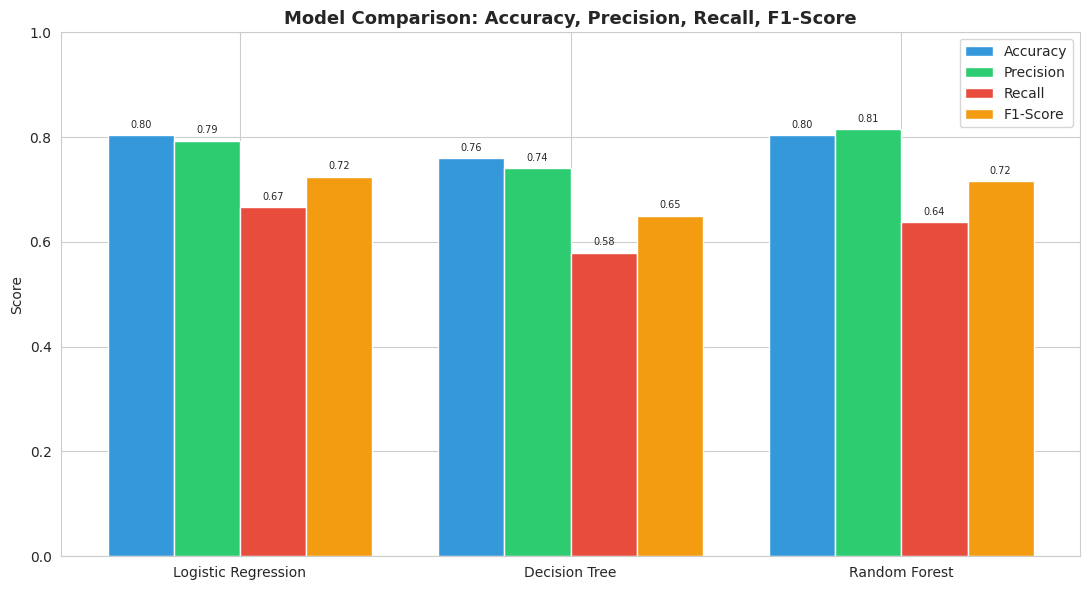

Figure saved!


In [31]:
# Bar chart: Model accuracy comparison
model_names = list(results.keys())
accuracies  = [res['accuracy']  for res in results.values()]
precisions  = [res['precision'] for res in results.values()]
recalls     = [res['recall']    for res in results.values()]
f1_scores   = [res['f1']        for res in results.values()]

x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - 1.5*width, accuracies,  width, label='Accuracy',  color='#3498db')
bars2 = ax.bar(x - 0.5*width, precisions,  width, label='Precision', color='#2ecc71')
bars3 = ax.bar(x + 0.5*width, recalls,     width, label='Recall',    color='#e74c3c')
bars4 = ax.bar(x + 1.5*width, f1_scores,   width, label='F1-Score',  color='#f39c12')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy, Precision, Recall, F1-Score', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.0)
ax.legend()

for bar in [*bars1, *bars2, *bars3, *bars4]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

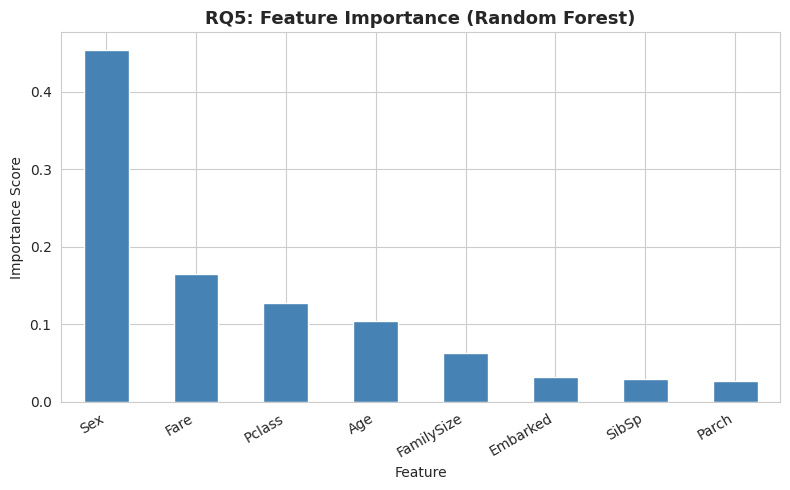

Figure saved!


In [32]:
# Research Q5: Feature importance from Random Forest
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='steelblue')
plt.title('RQ5: Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

## 8. Conclusions

### Answers to Research Questions:

1. **Passenger class** significantly affects survival — 1st class passengers survived at a much higher rate than 3rd class.
2. **Gender** is the strongest predictor — female passengers had a substantially higher survival rate than males.
3. **Age** shows that young children had higher survival rates; older adults fared worse.
4. **Family size** has a moderate effect — passengers traveling alone or with very large families survived less often.
5. **Most important features** (from Random Forest): Sex, Fare, Age, and Pclass were the top predictors.
6. **Best model**: Random Forest achieved the highest accuracy among the three models tested.
7. **Fare** is positively correlated with survival — passengers who paid higher fares (typically 1st class) survived more.

### Summary:
All three models successfully learned patterns from the Titanic dataset. Random Forest outperformed Logistic Regression and Decision Tree due to its ensemble nature. The project confirms that gender, class, and fare were the most critical survival factors aboard the Titanic.